# Bidirectional Encoder Representations from Transformers (BERT) - TREC-6 Question Classification

This project fine-tunes the pretrained `bert_base_en_uncased` model for six-class question classification using the TREC Question Classification dataset. The task is to predict the expected answer type of a question: abbreviation, entity, description, human, location, or numeric. The experiment demonstrates transfer learning with a pretrained Transformer using TensorFlow/Keras rather than training a Transformer encoder from scratch.


## 1. Import Required Libraries

Import TensorFlow/Keras, TensorFlow Datasets, KerasHub, and the evaluation libraries used throughout the experiment.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
import keras_hub

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow Version:", tf.__version__)
print("Keras Version:", keras.__version__)
print("KerasHub Version:", keras_hub.__version__)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("GPU Available:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.20.0
Keras Version: 3.15.1
KerasHub Version: 0.31.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load the TREC-6 Dataset

Load the TREC question classification dataset through TensorFlow Datasets and extract the six coarse-grained answer types.

In [3]:
trec_train = tfds.load(
    "trec",
    split="train"
)

trec_test = tfds.load(
    "trec",
    split="test"
)

train_items = list(
    tfds.as_numpy(trec_train)
)

test_items = list(
    tfds.as_numpy(trec_test)
)

train_texts = np.array([
    item["text"].decode("utf-8")
    if isinstance(item["text"], bytes)
    else str(item["text"])
    for item in train_items
], dtype=object)

train_labels = np.array([
    item["label-coarse"]
    for item in train_items
], dtype=np.int32)

test_texts = np.array([
    item["text"].decode("utf-8")
    if isinstance(item["text"], bytes)
    else str(item["text"])
    for item in test_items
], dtype=object)

test_labels = np.array([
    item["label-coarse"]
    for item in test_items
], dtype=np.int32)

class_names = [
    "ABBR",
    "ENTY",
    "DESC",
    "HUM",
    "LOC",
    "NUM"
]

print("Training Samples:", len(train_texts))
print("Test Samples:", len(test_texts))
print("Number of Classes:", len(class_names))
print("Classes:", class_names)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/trec/incomplete.HBRPOI_1.0.0/trec-train.tfrecord-[0-9][0-9][0-9][0-9][0-9]…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/trec/incomplete.HBRPOI_1.0.0/trec-test.tfrecord-[0-9][0-9][0-9][0-9][0-9]-…

Dataset trec downloaded and prepared to /root/tensorflow_datasets/trec/1.0.0. Subsequent calls will reuse this data.
Training Samples: 5452
Test Samples: 500
Number of Classes: 6
Classes: ['ABBR', 'ENTY', 'DESC', 'HUM', 'LOC', 'NUM']


## 3. Explore the Dataset

Inspect the class distribution and representative questions to understand the six answer-type categories.

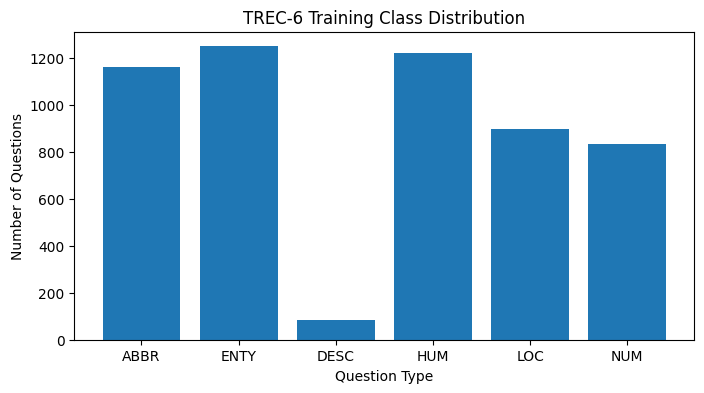

Class: ABBR
Question: What is the C programming language ?

Class: ENTY
Question: What is November 's birthstone ?

Class: DESC
Question: What is the abbreviation of the International Olympic Committee ?

Class: HUM
Question: Who was Camp David named for ?

Class: LOC
Question: How many claws has a lobster called a pistol lost ?

Class: NUM
Question: Where is the oldest living thing on earth ?



In [4]:
train_counts = np.bincount(
    train_labels,
    minlength=len(class_names)
)

plt.figure(figsize=(8, 4))
plt.bar(class_names, train_counts)
plt.xlabel("Question Type")
plt.ylabel("Number of Questions")
plt.title("TREC-6 Training Class Distribution")
plt.show()

for class_id, class_name in enumerate(class_names):
    index = np.where(train_labels == class_id)[0][0]
    print("=" * 90)
    print("Class:", class_name)
    print("Question:", train_texts[index])
    print()

## 4. Create Validation Split

Create a stratified validation set from the training data so model selection is based on unseen questions while preserving the class distribution.

In [5]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts,
    train_labels,
    test_size=0.1,
    random_state=SEED,
    stratify=train_labels
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))

Training Samples: 4906
Validation Samples: 546
Test Samples: 500


## 5. Build the Pretrained BERT Classifier

Load the pretrained BERT classifier and configure it for six TREC answer types. KerasHub handles the BERT preprocessing and model internals.

In [9]:
preprocessor = keras_hub.models.BertTextClassifierPreprocessor.from_preset(
    "bert_base_en_uncased",
    sequence_length=128
)

model = keras_hub.models.BertTextClassifier.from_preset(
    "bert_base_en_uncased",
    num_classes=len(class_names),
    preprocessor=preprocessor
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=2e-5
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Preset: bert_base_en_uncased")
print("Number of Classes:", len(class_names))

model.summary()

Preset: bert_base_en_uncased
Number of Classes: 6


Preprocessor: "bert_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ bert_tokenizer (BertTokenizer)                                │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "bert_text_classifier_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ segment_ids (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bert_backbone (BertBackbone)  │ [(None, 768), (None,      │     109,482,240 │ padding_mask[0][0],        │
│                               │ None, 768)]               │                 │ segment_ids[0][0],         │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 768)               │               0 │ bert_backbone[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 6)                 │           4,614 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 109,486,854 (417.66 MB)

 Trainable params: 109,486,854 (417.66 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Prepare Training and Evaluation Data

Create efficient TensorFlow datasets from the raw questions and labels. KerasHub performs BERT tokenization and preprocessing inside the model pipeline.

In [ ]:
batch_size = 16

train_data = tf.data.Dataset.from_tensor_slices(
    (train_texts, train_labels)
).shuffle(
    buffer_size=len(train_texts),
    seed=SEED,
    reshuffle_each_iteration=True
).batch(
    batch_size
).prefetch(
    tf.data.AUTOTUNE
)

val_data = tf.data.Dataset.from_tensor_slices(
    (val_texts, val_labels)
).batch(
    batch_size
).prefetch(
    tf.data.AUTOTUNE
)

test_data = tf.data.Dataset.from_tensor_slices(
    (test_texts, test_labels)
).batch(
    batch_size
).prefetch(
    tf.data.AUTOTUNE
)

print("Batch Size:", batch_size)

## 7. Fine-Tune BERT

Fine-tune the pretrained BERT classifier while monitoring validation accuracy and restore the best-performing weights.

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stopping]
)

best_epoch = int(
    np.argmax(
        history.history["val_accuracy"]
    ) + 1
)

print("Best Epoch:", best_epoch)
print(
    f"Best Validation Accuracy: "
    f"{history.history['val_accuracy'][best_epoch - 1]:.4f}"
)
print(
    f"Validation Loss at Best Epoch: "
    f"{history.history['val_loss'][best_epoch - 1]:.4f}"
)

## 8. Training Curves

Visualize training and validation accuracy and loss to assess convergence and generalization.

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Train"
)
plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BERT Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(
    history.history["loss"],
    marker="o",
    label="Train"
)
plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT Training and Validation Loss")
plt.legend()
plt.show()

## 9. Evaluate the Model

Evaluate the restored best BERT model on the held-out test set and generate predictions for detailed analysis.

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_data,
    verbose=1
)

logits = model.predict(
    test_data,
    verbose=1
)

test_predictions = np.argmax(
    logits,
    axis=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

## 10. Classification Report

Measure precision, recall, and F1-score for each TREC-6 answer type, along with macro and weighted averages.

In [ ]:
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=class_names,
        digits=4
    )
)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Weighted F1:     {weighted_f1:.4f}")

## 11. Confusion Matrix

Visualize class-level errors to identify answer types that are commonly confused.

In [ ]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

fig, ax = plt.subplots(
    figsize=(7, 7)
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("BERT TREC-6 Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. Error Analysis

Inspect representative misclassified questions to identify common failure patterns between closely related answer types.

In [ ]:
misclassified = np.where(
    test_predictions != test_labels
)[0]

print(
    "Misclassified Questions:",
    len(misclassified)
)

for index in misclassified[:10]:
    print("=" * 90)
    print("True Label     :", class_names[test_labels[index]])
    print("Predicted Label:", class_names[test_predictions[index]])
    print("Question       :", test_texts[index])

## 13. Key Findings



## 14. Conclusion

